# Contract Intelligence Multi-Agent System
## Assignment Notebook - 8-Week Capstone Project

**Course**: Agentic AI Bootcamp - Staff-Level System Design

---

## Welcome to Your Capstone Assignment!

This notebook is your guided journey to building a **production-grade multi-agent contract intelligence system**. Unlike the master solution, YOU will implement the core functionality.

### How This Assignment Works

1. **Scaffolding Provided**: Class structures, function signatures, and imports are given
2. **TODO Markers**: Look for `# TODO:` comments - these are YOUR tasks
3. **Hints**: Each section has hints to guide you (but not give away the answer)
4. **Validation Cells**: Run these to check if your implementation is correct
5. **Expected Output**: Sample outputs show what success looks like

### Difficulty Progression

| Week | Difficulty | Focus |
|------|-----------|-------|
| 1 | Easy | Environment setup (mostly provided) |
| 2 | Easy-Medium | Document processing methods |
| 3 | Medium | Vector store search functions |
| 4 | Medium-Hard | Implement agents from scratch |
| 5 | Hard | Multi-agent orchestration |
| 6 | Medium | Build knowledge graph |
| 7 | Medium | Add observability metrics |
| 8 | Hard | Integrate everything |

### Grading Rubric

- **Week 1-2**: 15% (Foundation)
- **Week 3-4**: 30% (Core Components)  
- **Week 5-6**: 30% (Advanced Features)
- **Week 7-8**: 25% (Production Polish)

Let's begin!

---

# WEEK 1: Environment & Foundations

**Difficulty: Easy** - Most code is provided. Focus on understanding.

---

## Learning Objectives

By the end of Week 1, you will:
- [ ] Set up all required packages
- [ ] Configure API keys securely
- [ ] Initialize Langfuse for observability
- [ ] Create traced wrapper functions
- [ ] Explore the contract data structure

---

## 1.1 Package Installation

This section is **provided** - just run the cell to install packages.

In [1]:
# ============================================================================
# WEEK 1.1: PACKAGE INSTALLATION (PROVIDED)
# ============================================================================
# Pinned versions for reproducibility. Every package is verified after install.

import subprocess, sys

_packages = ["openai==1.59.6", "langfuse==2.57.1", "langchain==0.3.14", "langchain-openai==0.2.14", "langchain-community==0.3.14", "langchain-core==0.3.29", "chromadb", "networkx", "pyvis", "python-docx", "openpyxl", "plotly", "seaborn", "pydantic>=2.0", "tenacity", "rich", "gradio", "python-dotenv", "numpy", "pandas", "matplotlib"]

print("Installing packages (this may take 1-2 minutes)...")
result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q"] + _packages,
    capture_output=True, text=True
)

if result.returncode != 0:
    for line in result.stderr.split("\n"):
        if line.strip() and "dependency resolver" not in line.lower() and "notice" not in line.lower():
            print(line)

# ---------- Verify EVERY import ----------
_verify = [
    ("openai", "openai"),
    ("langfuse", "langfuse"),
    ("langchain", "langchain"),
    ("langchain_openai", "langchain_openai"),
    ("chromadb", "chromadb"),
    ("networkx", "networkx"),
    ("pyvis", "pyvis.network"),
    ("docx", "docx"),
    ("openpyxl", "openpyxl"),
    ("plotly", "plotly"),
    ("seaborn", "seaborn"),
    ("pydantic", "pydantic"),
    ("tenacity", "tenacity"),
    ("rich", "rich"),
    ("gradio", "gradio"),
    ("dotenv", "dotenv"),
    ("fastapi", "fastapi"),
    ("uvicorn", "uvicorn"),
]

_failed = []
for name, imp in _verify:
    try:
        __import__(imp)
    except ImportError:
        _failed.append(name)

if _failed:
    msg = f"FATAL: These packages failed to import: {', '.join(_failed)}\n"
    msg += "Try: Runtime > Restart runtime, then re-run this cell."
    raise ImportError(msg)

print("=" * 60)
print(f"All {len(_verify)} packages installed and verified!")
print("=" * 60)

Installing packages (this may take 1-2 minutes)...


e:\Sheriff_faang\full_end_to_end_project_implementation\IK_PWC_Agentic_AI_Project\PWC_CAPSTONE_PROJECT\IK_PWC_COURSE_CAPSTONE_PROJECTS\.contract\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All 18 packages installed and verified!


## 1.2 Environment Configuration

This section is **provided** - handles environment detection and imports.

In [2]:
# ============================================================================
# WEEK 1.2: ENVIRONMENT DETECTION (PROVIDED)
# ============================================================================

import os
import sys
import json
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime
from typing import List, Dict, Optional, Any, Tuple
from dataclasses import dataclass, field
from enum import Enum
import warnings
warnings.filterwarnings('ignore')

# Environment detection
IN_COLAB = 'google.colab' in sys.modules

print(f"Runtime Environment: {'Google Colab' if IN_COLAB else 'Local/Other'}")
print(f"Python Version: {sys.version.split()[0]}")

Runtime Environment: Local/Other
Python Version: 3.12.7


In [3]:
# ============================================================================
# API KEY CONFIGURATION (PROVIDED)
# ============================================================================

import subprocess

DATASET_REPO = "https://github.com/AI-Project-Lab/IK-pwc-agenticai-datasets.git"
DATASET_PROJECT = "contract_intelligence"

if IN_COLAB:
    print("Configuring for Google Colab environment...")

    # --- API Key Configuration ---
    try:
        from google.colab import userdata
        os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')
        os.environ['LANGFUSE_SECRET_KEY'] = userdata.get('LANGFUSE_SECRET_KEY')
        os.environ['LANGFUSE_PUBLIC_KEY'] = userdata.get('LANGFUSE_PUBLIC_KEY')
        _host = userdata.get('LANGFUSE_HOST') or ''
        os.environ['LANGFUSE_HOST'] = _host if _host.startswith('http') else 'https://cloud.langfuse.com'
        print("API keys loaded from Colab Secrets")
    except Exception as e:
        print(f"Colab Secrets not available: {e}")
        import getpass
        os.environ['OPENAI_API_KEY'] = getpass.getpass('Enter OpenAI API Key: ')
        os.environ['LANGFUSE_SECRET_KEY'] = getpass.getpass('Enter Langfuse Secret Key: ')
        os.environ['LANGFUSE_PUBLIC_KEY'] = getpass.getpass('Enter Langfuse Public Key: ')
        os.environ['LANGFUSE_HOST'] = 'https://cloud.langfuse.com'

    # --- Dataset Ingestion from GitHub ---
    dataset_path = "/content/datasets"
    if not os.path.exists(f"{dataset_path}/{DATASET_PROJECT}"):
        print(f"\nCloning dataset from {DATASET_REPO}...")
        subprocess.run(["git", "clone", "--depth", "1", DATASET_REPO, dataset_path],
                       check=True, capture_output=True)
        print("Dataset cloned successfully!")
    else:
        print("\nDataset already available.")
    DATA_DIR_BASE = f"{dataset_path}/{DATASET_PROJECT}"
else:
    print("Configuring for local environment...")
    from dotenv import load_dotenv
    load_dotenv()

    # --- Dataset Ingestion from GitHub ---
    datasets_parent = Path('.').resolve().parent.parent / 'datasets'
    if not (datasets_parent / DATASET_PROJECT).exists():
        print(f"\nCloning dataset from {DATASET_REPO}...")
        subprocess.run(["git", "clone", "--depth", "1", DATASET_REPO, str(datasets_parent)],
                       check=True, capture_output=True)
        print("Dataset cloned successfully!")
    else:
        print("\nDataset already available locally.")
    DATA_DIR_BASE = str(datasets_parent / DATASET_PROJECT)

# Validate API keys
required_keys = ['OPENAI_API_KEY', 'LANGFUSE_SECRET_KEY', 'LANGFUSE_PUBLIC_KEY']
missing_keys = [key for key in required_keys if not os.environ.get(key)]
if missing_keys:
    raise EnvironmentError(f"Missing required API keys: {missing_keys}")

PROJECT_NAME = "contract-intelligence-system"
DATA_DIR = Path(DATA_DIR_BASE)
print(f"\nAll API keys validated successfully")
print(f"Data directory: {DATA_DIR}")
print(f"Directory exists: {DATA_DIR.exists()}")
if DATA_DIR.exists():
    file_count = sum(1 for _ in DATA_DIR.rglob('*') if _.is_file())
    print(f"Total files found: {file_count}")

Configuring for local environment...

Dataset already available locally.

All API keys validated successfully
Data directory: E:\Sheriff_faang\full_end_to_end_project_implementation\IK_PWC_Agentic_AI_Project\PWC_CAPSTONE_PROJECT\IK_PWC_COURSE_CAPSTONE_PROJECTS\datasets\contract_intelligence
Directory exists: True
Total files found: 36


## 1.3 Langfuse Initialization

**YOUR FIRST TODO!** Initialize the Langfuse client.

### Hints:
- Import `Langfuse` from `langfuse`
- Import `observe` and `langfuse_context` from `langfuse.decorators`
- Use environment variables for credentials
- Call `auth_check()` to verify connection

In [4]:
# ============================================================================
# WEEK 1.3: LANGFUSE INITIALIZATION
# ============================================================================
# TODO: Import necessary Langfuse modules

from langfuse import Langfuse
from langfuse.decorators import observe, langfuse_context
from openai import OpenAI

# TODO: Initialize the Langfuse client
# Hint: Use os.environ.get() to retrieve keys
# The constructor takes: secret_key, public_key, host

langfuse = Langfuse(
    secret_key=os.environ.get("LANGFUSE_SECRET_KEY"),
    public_key=os.environ.get("LANGFUSE_PUBLIC_KEY"),
    host=os.environ.get("LANGFUSE_HOST", "https://cloud.langfuse.com"),
)

# TODO: Verify connection
# Hint: Use langfuse.auth_check() in a try/except block

try:
    langfuse.auth_check()
    print("Langfuse connection verified!")
except Exception as exc:
    print(f"Langfuse auth check failed: {exc}")

# TODO: Create a unique session ID
# Hint: Use datetime.now().strftime() to create a unique identifier
# Format: "contract-intel-YYYYMMDD-HHMMSS"

SESSION_ID = datetime.now().strftime("contract-intel-%Y%m%d-%H%M%S")
print(f"Session ID: {SESSION_ID}")

Langfuse connection verified!
Session ID: contract-intel-20260914-144222


### Expected Output for 1.3:
```
Langfuse connection verified!
Session ID: contract-intel-20250127-143052
```

## 1.4 Traced Wrapper Functions

**TODO:** Implement traced versions of OpenAI calls.

### Hints:
- Create a trace with `langfuse.trace()`
- Create a generation span with `trace.generation()`
- Use `openai_client.embeddings.create()` for embeddings
- End the generation with usage stats

In [5]:
# ============================================================================
# WEEK 1.4: TRACED EMBEDDING FUNCTION
# ============================================================================

# Initialize OpenAI client (PROVIDED)
openai_client = OpenAI()

def traced_embedding(text: str, trace_name: str = "embedding") -> List[float]:
    """
    Generate embedding with full Langfuse tracing.

    Args:
        text: The text to embed
        trace_name: Identifier for this trace

    Returns:
        List of floats (embedding vector)

    TODO: Implement this function

    Steps:
    1. Create a trace with langfuse.trace()
    2. Create a generation span for the embedding call
    3. Call openai_client.embeddings.create()
    4. End the generation with output metadata
    5. Return the embedding
    """

    trace = langfuse.trace(
        name=trace_name,
        session_id=SESSION_ID,
        metadata={"type": "embedding", "model": "text-embedding-3-small"}
    )

    generation = trace.generation(
        name="openai-embedding",
        model="text-embedding-3-small",
        input={"text": text}
    )

    response = openai_client.embeddings.create(
        model="text-embedding-3-small",
        input=text
    )
    embedding = response.data[0].embedding

    generation.end(
        output={"embedding_length": len(embedding)},
        usage={
            "prompt_tokens": getattr(response.usage, "prompt_tokens", 0),
            "total_tokens": getattr(response.usage, "total_tokens", 0),
        }
    )

    return embedding

print("traced_embedding() function defined")

traced_embedding() function defined


In [6]:
# ============================================================================
# WEEK 1.4: TRACED COMPLETION FUNCTION
# ============================================================================

def traced_completion(prompt: str, trace_name: str = "completion") -> str:
    """
    Generate completion with full Langfuse tracing.

    Args:
        prompt: The prompt to complete
        trace_name: Identifier for this trace

    Returns:
        Generated text

    TODO: Implement this function (similar pattern to traced_embedding)
    """

    trace = langfuse.trace(
        name=trace_name,
        session_id=SESSION_ID,
        metadata={"type": "completion", "model": "gpt-4o-mini"}
    )

    generation = trace.generation(
        name="openai-completion",
        model="gpt-4o-mini",
        input={"prompt": prompt}
    )

    response = openai_client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}]
    )
    response_text = response.choices[0].message.content

    generation.end(
        output={"content": response_text},
        usage={
            "prompt_tokens": getattr(response.usage, "prompt_tokens", 0),
            "completion_tokens": getattr(response.usage, "completion_tokens", 0),
            "total_tokens": getattr(response.usage, "total_tokens", 0),
        }
    )

    return response_text

print("traced_completion() function defined")

traced_completion() function defined


## 1.5 Contract Document Taxonomy

**PROVIDED** - Study this structure carefully, you'll need it later.

In [7]:
# ============================================================================
# WEEK 1.5: CONTRACT TAXONOMY (PROVIDED)
# ============================================================================

CONTRACT_CATEGORIES = {
    'master_agreements': {
        'path': 'Master level agreements',
        'description': 'Foundation contracts establishing overall relationship',
        'document_types': ['MSA', 'NDA', 'Rate Cards'],
        'risk_focus': ['legal', 'compliance'],
    },
    'transaction_contracts': {
        'path': 'Transaction level contract',
        'description': 'Project-specific agreements under master agreements',
        'document_types': ['SOW', 'Work Orders', 'Renewals', 'Amendments'],
        'risk_focus': ['operational', 'financial'],
    },
    'commercial_docs': {
        'path': 'Commercial docs',
        'description': 'Pricing and commercial terms documentation',
        'document_types': ['Pricing Tables', 'Rate Schedules'],
        'risk_focus': ['financial'],
    },
    'financial_billing': {
        'path': 'Financial and Billing docs',
        'description': 'Invoices, payment records, and billing schedules',
        'document_types': ['Invoices', 'Credit Notes', 'Payment Schedules'],
        'risk_focus': ['financial'],
    },
    'operational_docs': {
        'path': 'Operational service delivery docs',
        'description': 'Service delivery and operational documentation',
        'document_types': ['Service Reports', 'SLA Reports'],
        'risk_focus': ['operational'],
    },
    'compliance_docs': {
        'path': 'Compliance and policy documents',
        'description': 'Security, compliance, and policy documentation',
        'document_types': ['InfoSec Controls', 'Vendor Policies'],
        'risk_focus': ['compliance'],
    },
    'legal_support': {
        'path': 'Legal support documents',
        'description': 'Legal correspondence and supporting documentation',
        'document_types': ['Legal Memos', 'Correspondence'],
        'risk_focus': ['legal'],
    },
    'relationship_governance': {
        'path': 'Relationship and governance docs',
        'description': 'Governance frameworks and relationship management',
        'document_types': ['Governance Frameworks', 'Escalation Matrices'],
        'risk_focus': ['operational', 'compliance'],
    }
}

print(f"Contract categories defined: {len(CONTRACT_CATEGORIES)}")
for cat, info in CONTRACT_CATEGORIES.items():
    print(f"  - {cat}: {info['description'][:50]}...")

Contract categories defined: 8
  - master_agreements: Foundation contracts establishing overall relation...
  - transaction_contracts: Project-specific agreements under master agreement...
  - commercial_docs: Pricing and commercial terms documentation...
  - financial_billing: Invoices, payment records, and billing schedules...
  - operational_docs: Service delivery and operational documentation...
  - compliance_docs: Security, compliance, and policy documentation...
  - legal_support: Legal correspondence and supporting documentation...
  - relationship_governance: Governance frameworks and relationship management...


## 1.6 Data Discovery

**TODO:** Implement the data discovery function.

### Hints:
- Use `Path.rglob('*')` to recursively find files
- Check file suffixes with `item.suffix.lower()`
- Create spans for each category scan

In [8]:
# ============================================================================
# WEEK 1.6: DATA DISCOVERY FUNCTION
# ============================================================================

def discover_contract_data(data_dir: Path) -> Dict[str, List[Path]]:
    """
    Discover all contract documents organized by category.

    Args:
        data_dir: Path to the root data directory

    Returns:
        Dictionary mapping categories to lists of file paths

    TODO: Implement this function

    Steps:
    1. Create a trace for data discovery
    2. Initialize discovered dict with empty lists for each category
    3. For each category, scan the appropriate subdirectory
    4. Find all .docx, .pdf, .xlsx files
    5. Log results to Langfuse
    """

    trace = langfuse.trace(
        name="discover-contract-data",
        session_id=SESSION_ID,
        input={"data_dir": str(data_dir)}
    )

    discovered = {cat: [] for cat in CONTRACT_CATEGORIES.keys()}

    if not data_dir.exists():
        candidates = [
            data_dir,
            Path(DATA_DIR_BASE) if 'DATA_DIR_BASE' in globals() else data_dir,
            Path('datasets') / 'contract_intelligence',
            Path('..') / 'datasets' / 'contract_intelligence',
            Path('../datasets/contract_intelligence'),
        ]
        existing = next((p for p in candidates if p.exists()), None)
        if existing is not None:
            data_dir = existing
        else:
            trace.update(output={"status": "missing", "path": str(data_dir)})
            return discovered

    total_files = 0
    for category, info in CONTRACT_CATEGORIES.items():
        category_path = data_dir / info['path']
        if not category_path.exists():
            continue
        for item in sorted(category_path.rglob('*')):
            if not item.is_file():
                continue
            if item.suffix.lower() in {'.docx', '.pdf', '.xlsx'}:
                discovered[category].append(item)
                total_files += 1

    trace.update(output={"status": "success", "total_files": total_files, "categories": {k: len(v) for k, v in discovered.items()}})

    return discovered

# Set up data path
if IN_COLAB:
    DATA_DIR = Path('/content/data')
else:
    DATA_DIR = Path(DATA_DIR_BASE) if 'DATA_DIR_BASE' in globals() else Path('../data')

# Run discovery
contract_files = discover_contract_data(DATA_DIR)

print("\nDiscovery Summary:")
total = 0
for cat, files in contract_files.items():
    if files:
        print(f"  {cat}: {len(files)} files")
        total += len(files)
print(f"\nTotal files discovered: {total}")


Discovery Summary:
  master_agreements: 6 files
  transaction_contracts: 4 files
  commercial_docs: 2 files
  financial_billing: 4 files
  operational_docs: 4 files
  compliance_docs: 6 files

Total files discovered: 26


## Checkpoint: Week 1 Verification

Run this cell to verify your Week 1 implementation.

In [9]:
# ============================================================================
# WEEK 1 CHECKPOINT - VALIDATION
# ============================================================================

print("WEEK 1 CHECKPOINT - Verification")
print("=" * 60)

checks = []

# Check 1: Langfuse initialized
try:
    checks.append(("Langfuse initialized", langfuse is not None))
except:
    checks.append(("Langfuse initialized", False))

# Check 2: Session ID created
try:
    checks.append(("Session ID created", SESSION_ID is not None and len(SESSION_ID) > 10))
except:
    checks.append(("Session ID created", False))

# Check 3: OpenAI client ready
try:
    checks.append(("OpenAI client ready", openai_client is not None))
except:
    checks.append(("OpenAI client ready", False))

# Check 4: traced_embedding works
try:
    test_emb = traced_embedding("test", "test-validation")
    checks.append(("traced_embedding() works", test_emb is not None and len(test_emb) == 1536))
except Exception as e:
    checks.append(("traced_embedding() works", False))
    print(f"  Error: {e}")

# Check 5: traced_completion works
try:
    test_comp = traced_completion("Say 'hello'", "test-validation")
    checks.append(("traced_completion() works", test_comp is not None and len(test_comp) > 0))
except Exception as e:
    checks.append(("traced_completion() works", False))
    print(f"  Error: {e}")

# Check 6: Contract taxonomy
checks.append(("Contract taxonomy defined", len(CONTRACT_CATEGORIES) == 8))

# Check 7: Data discovery
try:
    checks.append(("Data discovery function works", callable(discover_contract_data)))
except:
    checks.append(("Data discovery function works", False))

# Display results
all_passed = True
for check_name, check_result in checks:
    status = "PASS" if check_result else "FAIL"
    print(f"  [{status}] {check_name}")
    if not check_result:
        all_passed = False

print("\n" + "=" * 60)
if all_passed:
    print("ALL WEEK 1 CHECKPOINTS PASSED! Ready for Week 2.")
else:
    print("Some checkpoints FAILED. Review your implementation above.")
    print("\nHint: Check the error messages and compare with expected output.")

WEEK 1 CHECKPOINT - Verification
  [PASS] Langfuse initialized
  [PASS] Session ID created
  [PASS] OpenAI client ready
  [PASS] traced_embedding() works
  [PASS] traced_completion() works
  [PASS] Contract taxonomy defined
  [PASS] Data discovery function works

ALL WEEK 1 CHECKPOINTS PASSED! Ready for Week 2.


---

# WEEK 2: Document Processing & EDA

**Difficulty: Easy-Medium** - Implement document parsing methods.

---

## Learning Objectives

By the end of Week 2, you will:
- [ ] Load and parse DOCX contract files
- [ ] Extract text from tables
- [ ] Identify document sections
- [ ] Perform exploratory data analysis
- [ ] Extract contract entities

---

## 2.1 Document Processor Class

**TODO:** Implement the core document processing methods.

### Hints:
- Use `python-docx` library (already imported as `Document`)
- Paragraphs are in `doc.paragraphs`
- Tables are in `doc.tables`
- Use regex patterns to identify section headers

In [17]:
from docx import Document as DocxDocument
import re
import hashlib

class ContractDocumentProcessor:
    """
    Production-grade document processor for contract analysis.

    YOU MUST IMPLEMENT:
    - load_docx(): Load and parse a DOCX file
    - extract_tables(): Extract text from tables
    - extract_sections(): Identify document sections
    - process_category(): Process all documents in a category
    """

    def __init__(self):
        self.supported_formats = ['.docx']
        self.processed_docs = []

        # Section header patterns (PROVIDED)
        self.section_patterns = [
            r'^(\d+\.\s+[A-Z][A-Z\s]+)$',      # "1. DEFINITIONS"
            r'^(\d+\.\d+\s+.+)$',              # "1.1 Term"
            r'^(ARTICLE\s+[IVXLCDM]+)',          # "ARTICLE I"
            r'^(SECTION\s+\d+)',                # "SECTION 1"
            r'^(Schedule\s+[A-Z0-9]+)',          # "Schedule A"
            r'^(Exhibit\s+[A-Z0-9]+)',           # "Exhibit A"
        ]

    def load_docx(self, file_path: Path, trace_parent=None) -> Optional[Dict[str, Any]]:
        """
        Load and parse a DOCX contract file.

        Args:
            file_path: Path to the DOCX file
            trace_parent: Parent trace for nested spans

        Returns:
            Dictionary with parsed document data, or None on error
        """
        span = trace_parent.span(name=f"load-{file_path.name}") if trace_parent and hasattr(trace_parent, "span") else None

        try:
            doc = DocxDocument(str(file_path))

            paragraphs = []
            for paragraph in doc.paragraphs:
                text = (paragraph.text or "").strip()
                if text:
                    paragraphs.append(text)

            table_text = self.extract_tables(doc)
            full_text = "\n".join(paragraphs)
            if table_text.strip():
                full_text = full_text + ("\n" if full_text else "") + table_text

            doc_id = hashlib.md5(str(file_path).encode("utf-8")).hexdigest()[:12]
            sections = self.extract_sections(full_text)

            if span:
                span.end(output={"status": "success", "text_length": len(full_text)})

            return {
                'doc_id': doc_id,
                'filename': file_path.name,
                'file_path': str(file_path),
                'full_text': full_text,
                'table_text': table_text,
                'sections': sections,
                'word_count': len(full_text.split())
            }

        except Exception as e:
            if span:
                span.end(output={"status": "error", "error": str(e)})
            print(f"Error loading {file_path}: {e}")
            return None

    def extract_tables(self, doc) -> str:
        """Extract text from all tables in a document."""
        table_texts = []

        for table in doc.tables:
            row_texts = []
            for row in table.rows:
                cell_values = []
                for cell in row.cells:
                    value = (cell.text or "").strip()
                    if value:
                        cell_values.append(value)
                if cell_values:
                    row_texts.append(" | ".join(cell_values))
            if row_texts:
                table_texts.append("\n".join(row_texts))

        return "\n\n".join(table_texts)

    def extract_sections(self, text: str) -> List[Dict[str, str]]:
        """Extract sections from document text using regex patterns."""
        sections = []
        lines = text.splitlines()

        for position, line in enumerate(lines):
            normalized = line.strip()
            if not normalized:
                continue
            for pattern in self.section_patterns:
                if re.match(pattern, normalized, re.IGNORECASE):
                    sections.append({"header": normalized, "position": position})
                    break

        return sections

print("ContractDocumentProcessor class defined")
print("Document parsing methods implemented")

ContractDocumentProcessor class defined
Document parsing methods implemented


### Expected Output for load_docx():
```python
{
    'doc_id': 'ABC123...',
    'filename': 'sample_msa.docx',
    'full_text': 'MASTER SERVICE AGREEMENT...',
    'table_text': 'Service | Price | Term...',
    'sections': [{'header': '1. DEFINITIONS', 'position': 0}, ...],
    'word_count': 5432
}
```

In [18]:
def process_category(self, files: List[Path], category: str) -> List[Dict]:
    """
    Process all documents in a category with tracing.

    Args:
        files: List of file paths
        category: Category name

    Returns:
        List of processed document dictionaries
    """
    trace = langfuse.trace(
        name=f"process-{category}",
        session_id=SESSION_ID,
        input={"category": category, "file_count": len(files)}
    )

    processed = []

    for file_path in files:
        if file_path.suffix.lower() not in self.supported_formats:
            continue

        parsed = self.load_docx(file_path, trace_parent=trace)
        if parsed is None:
            continue

        parsed['category'] = category
        processed.append(parsed)

    trace.update(output={"processed_count": len(processed)})
    self.processed_docs.extend(processed)

    return processed

ContractDocumentProcessor.process_category = process_category

print("process_category() method added")

process_category() method added


## 2.2 Process All Documents

Run your document processor on all discovered files.

In [24]:
# ==========================================================================
# WEEK 2.2: PROCESS ALL DOCUMENTS
# ============================================================================

from pprint import pprint

# Initialize processor
doc_processor = ContractDocumentProcessor()

print("PROCESSING CONTRACT DOCUMENTS")
print("=" * 60)

# Process all categories
all_contract_docs = {}
for category, files in contract_files.items():
    if files:
        all_contract_docs[category] = doc_processor.process_category(files, category)
        print(f"{category}: {len(all_contract_docs[category])} documents processed")

# Flatten all documents
all_docs_flat = []
for docs in all_contract_docs.values():
    all_docs_flat.extend(docs)

print(f"\n" + "=" * 60)
print(f"TOTAL DOCUMENTS PROCESSED: {len(all_docs_flat)}")

# If no real documents, create sample data
if not all_docs_flat:
    print("\nNo documents found - creating sample data for demonstration...")
    sample_contract_text = """
MASTER SERVICE AGREEMENT

This Master Service Agreement ("Agreement") is entered into as of January 1, 2024
between TechCorp Inc. ("Client") and ServicePro LLC ("Provider").

1. DEFINITIONS
   "Services" means the professional services described in any Statement of Work.
   "Confidential Information" means any non-public information disclosed by either party.

2. SERVICES AND DELIVERABLES
   Provider shall perform the Services described in each Statement of Work.
   All deliverables shall meet the specifications set forth in the applicable SOW.

3. PAYMENT TERMS
   Client shall pay Provider within Net 30 days of invoice receipt.
   Late payments shall accrue interest at 1.5% per month.
   Total contract value: $500,000 over 24 months.

4. LIABILITY
   Provider's total liability shall not exceed the fees paid in the prior 12 months.
   Neither party shall be liable for consequential, indirect, or punitive damages.

5. INDEMNIFICATION
   Each party shall indemnify the other against third-party claims arising from
   their negligence or willful misconduct.

6. TERMINATION
   Either party may terminate with 30 days written notice.
   Client may terminate for cause immediately upon material breach.
"""

    all_docs_flat = [{
        'doc_id': 'SAMPLE-001',
        'filename': 'sample_msa.docx',
        'category': 'master_agreements',
        'full_text': sample_contract_text,
        'table_text': '',
        'sections': [{'header': '1. DEFINITIONS', 'position': 0}],
        'word_count': len(sample_contract_text.split())
    }]

    print(f"Sample document created with {all_docs_flat[0]['word_count']} words")

# Display the complete details for one document using real parsed values.
if all_docs_flat:
    print("\nDETAILS FOR ONE DOCUMENT")
    print("=" * 60)
    pprint(all_docs_flat[0], sort_dicts=False, width=120)
else:
    print("\nNo document details available to display.")

langfuse.flush()


PROCESSING CONTRACT DOCUMENTS
master_agreements: 6 documents processed
transaction_contracts: 4 documents processed
commercial_docs: 2 documents processed
financial_billing: 4 documents processed
operational_docs: 4 documents processed
compliance_docs: 6 documents processed

TOTAL DOCUMENTS PROCESSED: 26

DETAILS FOR ONE DOCUMENT
{'doc_id': '05403fbd35b4',
 'filename': 'MSA Sample 1.docx',
 'file_path': 'E:\\Sheriff_faang\\full_end_to_end_project_implementation\\IK_PWC_Agentic_AI_Project\\PWC_CAPSTONE_PROJECT\\IK_PWC_COURSE_CAPSTONE_PROJECTS\\datasets\\contract_intelligence\\Master '
              'level agreements\\MSA Sample 1.docx',
 'full_text': 'MASTER SERVICES AGREEMENT (MSA SAMPLE 1)\n'
              'Between PrimeVolta Hardware Solutions & FinSecure Services\n'
              '1. DEFINITIONS\n'
              'For the purposes of this Master Services Agreement (“Agreement”), the following terms shall carry the '
              'meanings assigned to them herein. “Agreement” refers 

## 2.3 Exploratory Data Analysis (EDA)

**TODO:** Create visualizations to understand the contract corpus.

### Hints:
- Use matplotlib/seaborn for visualizations
- Create charts for: category distribution, word counts, section counts

EXPLORATORY DATA ANALYSIS


EXPLORATORY DATA ANALYSIS


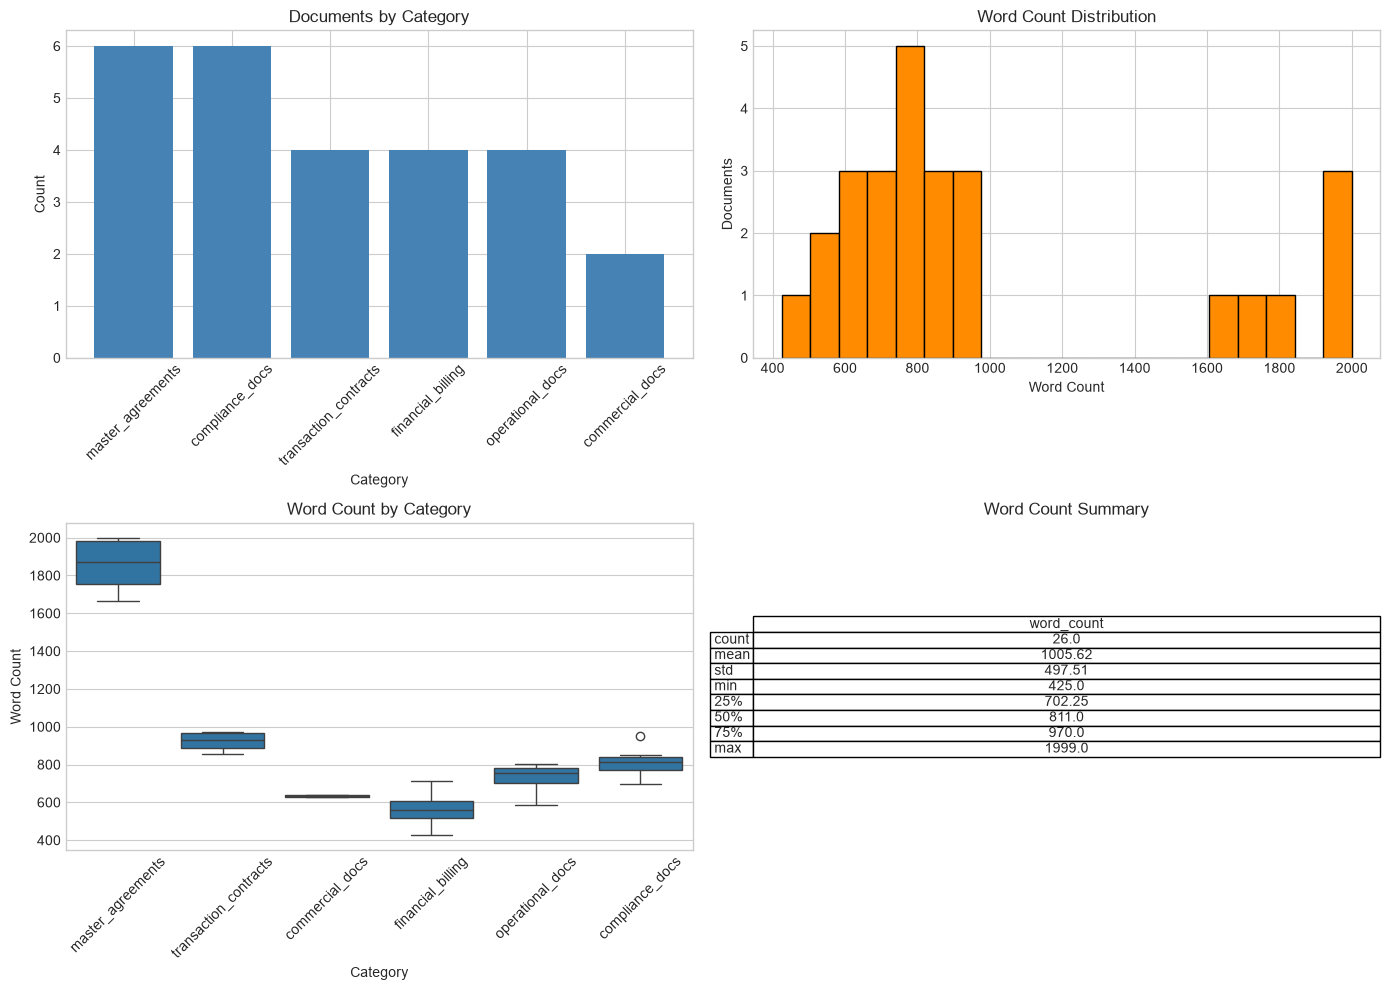


EDA visualizations saved to contract_eda.png


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')

print("EXPLORATORY DATA ANALYSIS")
print("=" * 60)

df = pd.DataFrame(all_docs_flat)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Category distribution
category_counts = df['category'].value_counts()
axes[0, 0].bar(category_counts.index.astype(str), category_counts.values, color='steelblue')
axes[0, 0].set_title('Documents by Category')
axes[0, 0].set_xlabel('Category')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)

# Word count histogram
axes[0, 1].hist(df['word_count'].fillna(0), bins=20, color='darkorange', edgecolor='black')
axes[0, 1].set_title('Word Count Distribution')
axes[0, 1].set_xlabel('Word Count')
axes[0, 1].set_ylabel('Documents')

# Word count by category boxplot
if not df.empty:
    sns.boxplot(data=df, x='category', y='word_count', ax=axes[1, 0])
    axes[1, 0].set_title('Word Count by Category')
    axes[1, 0].set_xlabel('Category')
    axes[1, 0].set_ylabel('Word Count')
    axes[1, 0].tick_params(axis='x', rotation=45)
else:
    axes[1, 0].text(0.5, 0.5, 'No data', ha='center', va='center')
    axes[1, 0].set_axis_off()

# Summary statistics
summary = df[['word_count']].describe().round(2)
axes[1, 1].axis('off')
axes[1, 1].table(
    cellText=summary.values,
    rowLabels=summary.index,
    colLabels=summary.columns,
    cellLoc='center',
    loc='center'
)
axes[1, 1].set_title('Word Count Summary')

plt.tight_layout()
plt.savefig('contract_eda.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nEDA visualizations saved to contract_eda.png")

## 2.4 Contract Entity Extraction

**TODO:** Implement entity extraction using regex patterns.

### Hints:
- Use `re.findall()` for pattern matching
- Common entities: parties, dates, monetary values, percentages
- Risk indicators: liability terms, termination clauses

In [21]:
class ContractEntityExtractor:
    """
    Extract contract-specific entities using pattern matching.

    TODO: Implement extract_entities() and assess_risk_indicators()
    """

    def __init__(self):
        # Extraction patterns (PROVIDED)
        self.patterns = {
            'parties': r'(?:between|by and between)\s+([A-Z][A-Za-z\s]+(?:Inc\.|LLC|Ltd\.|Corp\.)?)',
            'effective_date': r'(?:effective\s+(?:as\s+of\s+)?(?:date)?:?\s*)(\d{1,2}[/-]\d{1,2}[/-]\d{2,4}|[A-Z][a-z]+\s+\d{1,2},?\s+\d{4})',
            'monetary_values': r'\$([\d,]+(?:\.\d{2})?)',
            'percentages': r'(\d+(?:\.\d+)?\s*%)',
            'durations': r'(\d+)\s*(?:years?|months?|days?)',
            'notice_periods': r'(?:notice\s+(?:period)?\s*(?:of)?\s*)(\d+)\s*(?:days?)',
        }

        # Risk indicators (PROVIDED)
        self.risk_indicators = {
            'high_risk': [
                'unlimited liability', 'indemnify', 'consequential damages',
                'punitive damages', 'sole discretion', 'automatic renewal'
            ],
            'medium_risk': [
                'liability cap', 'limitation of liability', 'force majeure',
                'material breach', 'termination for convenience'
            ],
            'low_risk': [
                'mutual indemnification', 'standard terms', 'annual review'
            ]
        }

    def extract_entities(self, text: str) -> Dict[str, List[str]]:
        """
        Extract all entities from contract text.

        Args:
            text: Contract text

        Returns:
            Dictionary mapping entity types to found values
        """
        entities = {}
        lowered = text or ""

        for name, pattern in self.patterns.items():
            matches = re.findall(pattern, lowered, flags=re.IGNORECASE)
            if matches:
                entities[name] = []
                for match in matches:
                    value = match.strip() if isinstance(match, str) else str(match).strip()
                    if value:
                        entities[name].append(value)

        return entities

    def assess_risk_indicators(self, text: str) -> Dict[str, List[str]]:
        """
        Identify risk indicators in contract text.

        Args:
            text: Contract text

        Returns:
            Dictionary with found risk indicators by level
        """
        found_risks = {'high_risk': [], 'medium_risk': [], 'low_risk': []}
        lowered = (text or '').lower()

        for level, indicators in self.risk_indicators.items():
            for indicator in indicators:
                if indicator.lower() in lowered:
                    found_risks[level].append(indicator)

        return found_risks

# Initialize extractor
entity_extractor = ContractEntityExtractor()

print("ContractEntityExtractor class defined")
print("Entity extraction and risk assessment implemented")

ContractEntityExtractor class defined
Entity extraction and risk assessment implemented


In [22]:
# ============================================================================
# TEST ENTITY EXTRACTION
# ============================================================================

# Test on sample document
if all_docs_flat:
    test_doc = all_docs_flat[0]
    print(f"Testing entity extraction on: {test_doc['filename']}")
    print("=" * 60)

    # Extract entities
    entities = entity_extractor.extract_entities(test_doc['full_text'])
    print("\nExtracted Entities:")
    for entity_type, values in entities.items():
        if values:
            print(f"  {entity_type}: {values[:3]}...")  # Show first 3

    # Assess risk
    risks = entity_extractor.assess_risk_indicators(test_doc['full_text'])
    print("\nRisk Indicators Found:")
    for level, indicators in risks.items():
        if indicators:
            print(f"  {level}: {indicators}")

Testing entity extraction on: MSA Sample 1.docx

Extracted Entities:
  parties: ['PrimeVolta Hardware Solutions', 'the Parties specifying the exact scope', 'the Parties']...
  percentages: ['1%']...

Risk Indicators Found:
  high_risk: ['indemnify', 'punitive damages']
  medium_risk: ['limitation of liability']


## Checkpoint: Week 2 Verification

In [23]:
# ============================================================================
# WEEK 2 CHECKPOINT - VALIDATION
# ============================================================================

print("WEEK 2 CHECKPOINT - Verification")
print("=" * 60)

checks = []

# Check 1: Document processor exists
checks.append(("DocumentProcessor initialized", doc_processor is not None))

# Check 2: load_docx method works
try:
    # Test with sample text (doesn't need real file)
    test_result = doc_processor.load_docx is not None
    checks.append(("load_docx() method exists", test_result))
except:
    checks.append(("load_docx() method exists", False))

# Check 3: Documents processed
checks.append(("Documents processed", len(all_docs_flat) > 0))

# Check 4: Entity extractor works
try:
    test_entities = entity_extractor.extract_entities("Contract value is $100,000")
    has_monetary = 'monetary_values' in test_entities
    checks.append(("Entity extraction works", has_monetary))
except Exception as e:
    checks.append(("Entity extraction works", False))
    print(f"  Error: {e}")

# Check 5: Risk assessment works
try:
    test_risks = entity_extractor.assess_risk_indicators("unlimited liability clause")
    has_high = len(test_risks.get('high_risk', [])) > 0
    checks.append(("Risk assessment works", has_high))
except Exception as e:
    checks.append(("Risk assessment works", False))
    print(f"  Error: {e}")

# Display results
all_passed = True
for check_name, check_result in checks:
    status = "PASS" if check_result else "FAIL"
    print(f"  [{status}] {check_name}")
    if not check_result:
        all_passed = False

print("\n" + "=" * 60)
if all_passed:
    print("ALL WEEK 2 CHECKPOINTS PASSED! Ready for Week 3.")
else:
    print("Some checkpoints FAILED. Review your implementation above.")

WEEK 2 CHECKPOINT - Verification
  [PASS] DocumentProcessor initialized
  [PASS] load_docx() method exists
  [PASS] Documents processed
  [PASS] Entity extraction works
  [PASS] Risk assessment works

ALL WEEK 2 CHECKPOINTS PASSED! Ready for Week 3.
